In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"
rainfall = pd.read_csv(  path + r"\Rainfall_ML.csv")


In [3]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29583 entries, 0 to 29582
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             29583 non-null  int64  
 1   date           29583 non-null  object 
 2   state_code     29583 non-null  int64  
 3   state_name     29583 non-null  object 
 4   district_code  29583 non-null  int64  
 5   district_name  29583 non-null  object 
 6   actual         29259 non-null  float64
 7   rfs            29583 non-null  float64
 8   normal         29565 non-null  float64
 9   deviation      26121 non-null  float64
 10  agri_year      29583 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.5+ MB


In [4]:
rainfall.columns

Index(['id', 'date', 'state_code', 'state_name', 'district_code',
       'district_name', 'actual', 'rfs', 'normal', 'deviation', 'agri_year'],
      dtype='object')

In [5]:
rainfall.columns

Index(['id', 'date', 'state_code', 'state_name', 'district_code',
       'district_name', 'actual', 'rfs', 'normal', 'deviation', 'agri_year'],
      dtype='object')

In [6]:
rainfall.shape

(29583, 11)

In [7]:
rainfall.dtypes

id                 int64
date              object
state_code         int64
state_name        object
district_code      int64
district_name     object
actual           float64
rfs              float64
normal           float64
deviation        float64
agri_year         object
dtype: object

In [8]:
print(
    rainfall["district_name"].value_counts()
)

district_name
Nizamabad       3287
Karimnagar      3287
Khammam         3287
Mahabubnagar    3287
Medak           3287
Adilabad        3287
Nalgonda        3287
Ranga Reddy     3287
Warangal        3287
Name: count, dtype: int64


In [9]:
rainfall.loc[
    (rainfall["actual"] == 0)
    & (rainfall["normal"] == 0)
    & (rainfall["deviation"].isnull()),
    "deviation"
] = 0

In [10]:
print(
    rainfall[
        ["actual", "normal", "deviation"]
    ].isnull().sum()
)

actual       324
normal        18
deviation    594
dtype: int64


In [11]:
print(
    rainfall[
        ["actual", "normal", "deviation"]
    ].isnull().value_counts()
)

actual  normal  deviation
False   False   False        28989
True    False   True           324
False   False   True           252
        True    True            18
Name: count, dtype: int64


In [12]:
# Convert date correctly
rainfall["date"] = pd.to_datetime(
    rainfall["date"],
    errors="coerce"
)

# Create month
rainfall["month"] = rainfall["date"].dt.month

print("Date nulls:", rainfall["date"].isna().sum())
print("Month nulls:", rainfall["month"].isna().sum())

Date nulls: 0
Month nulls: 0


In [13]:
# Fill normal using district + month median
rainfall["normal"] = rainfall["normal"].fillna(
    rainfall.groupby(
        ["district_name", "month"]
    )["normal"].transform("median")
)

# Fill actual using district + month median
rainfall["actual"] = rainfall["actual"].fillna(
    rainfall.groupby(
        ["district_name", "month"]
    )["actual"].transform("median")
)

In [14]:
## deviation  as percentage
rainfall["deviation"] = np.where(
    rainfall["normal"] != 0,
    ((rainfall["actual"] - rainfall["normal"]) / rainfall["normal"]) * 100,
    0
)

In [15]:
print(rainfall.isnull().sum())

id               0
date             0
state_code       0
state_name       0
district_code    0
district_name    0
actual           0
rfs              0
normal           0
deviation        0
agri_year        0
month            0
dtype: int64


In [16]:
rainfall[
    ["actual", "normal", "deviation"]
].describe()

,actual,normal,deviation
count,29583.000000,29583.000000,29583.000000
mean,2.878144,2.592475,43.426606
std,7.989371,3.156027,747.113575
min,0.000000,0.000000,-100.000000
25%,0.000000,0.200000,-100.000000
50%,0.000000,0.800000,-93.076923
75%,1.790000,4.700000,0.000000
max,156.680000,18.400000,37470.000000


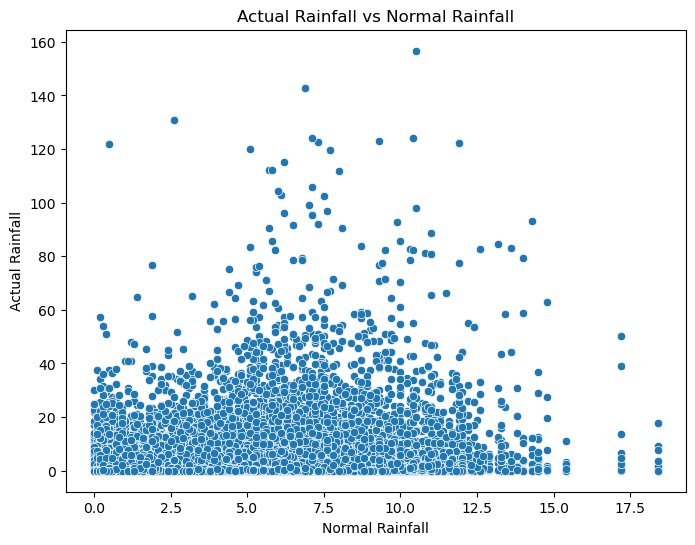

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rainfall,
    x="normal",
    y="actual"
)

plt.title("Actual Rainfall vs Normal Rainfall")
plt.xlabel("Normal Rainfall")
plt.ylabel("Actual Rainfall")

plt.show()

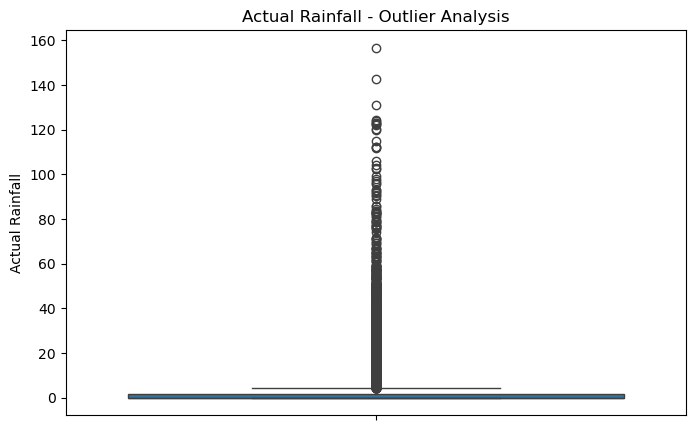

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=rainfall["actual"]
)

plt.title("Actual Rainfall - Outlier Analysis")
plt.ylabel("Actual Rainfall")

plt.show()

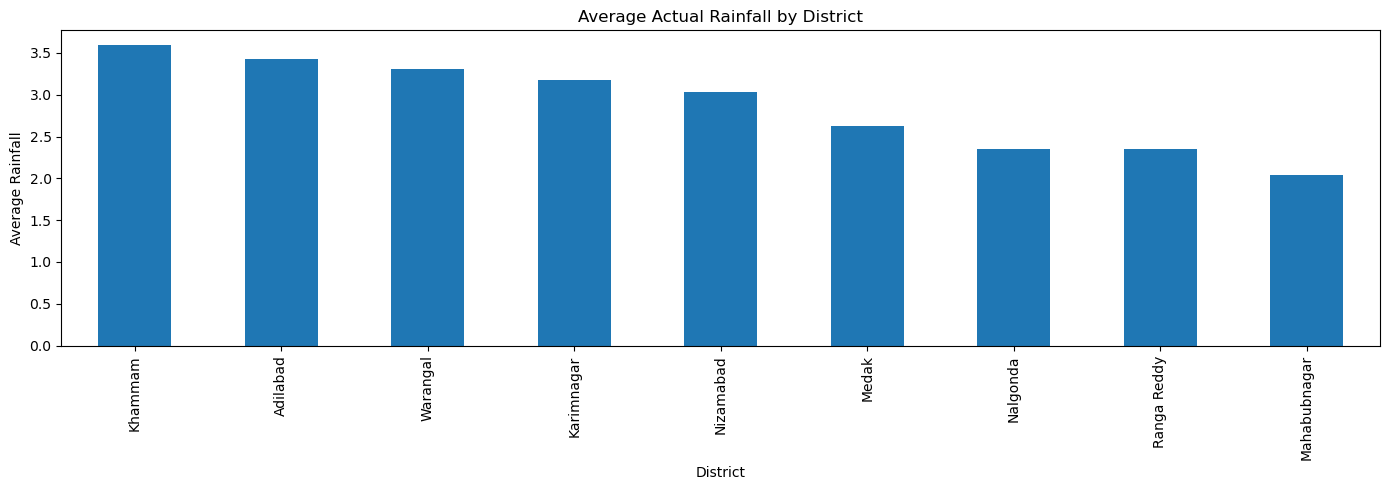

In [19]:
district_rainfall = (
    rainfall.groupby("district_name")["actual"]
    .mean()
    .sort_values(ascending=False)
)

district_rainfall.plot(
    kind="bar",
    figsize=(14, 5)
)

plt.title("Average Actual Rainfall by District")
plt.xlabel("District")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
corr = rainfall[
    ["actual", "normal", "deviation"]
].corr()

print(corr)

             actual    normal  deviation
actual     1.000000  0.376165   0.312077
normal     0.376165  1.000000  -0.036511
deviation  0.312077 -0.036511   1.000000


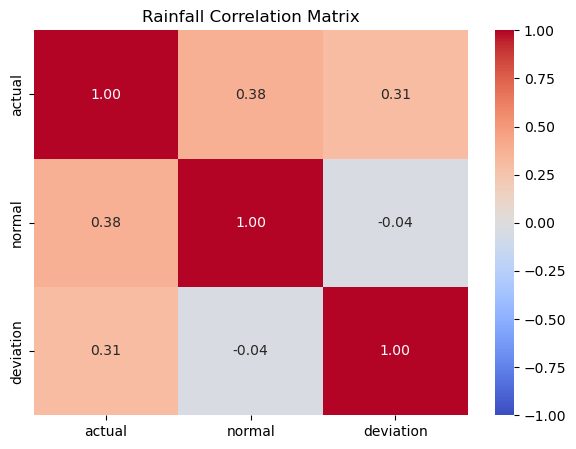

In [21]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Rainfall Correlation Matrix")
plt.show()

In [22]:
rainfall["rainfall_status"] = np.where(
    rainfall["deviation"] < 0,
    "Below Normal",
    np.where(
        rainfall["deviation"] > 0,
        "Above Normal",
        "Normal"
    )
)

print(
    rainfall["rainfall_status"].value_counts()
)

rainfall_status
Below Normal    20712
Above Normal     5720
Normal           3151
Name: count, dtype: int64


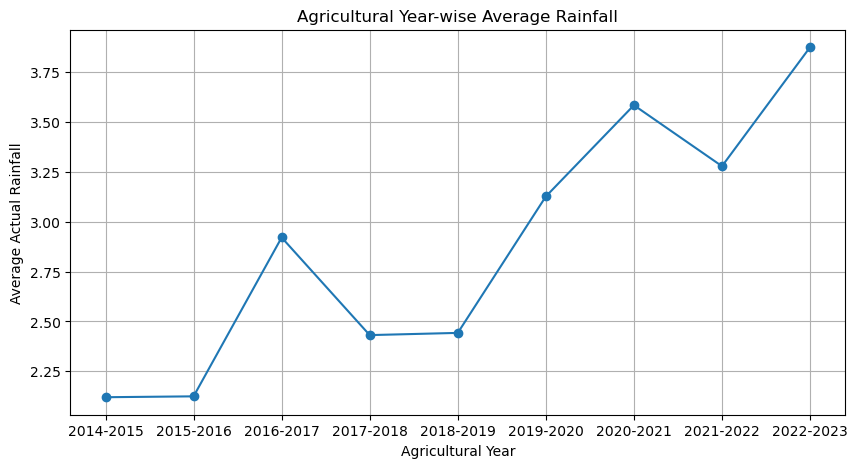

In [23]:
yearly_rainfall = (
    rainfall.groupby("agri_year")["actual"]
    .mean()
)

yearly_rainfall.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Agricultural Year-wise Average Rainfall")
plt.xlabel("Agricultural Year")
plt.ylabel("Average Actual Rainfall")
plt.grid()
plt.show()

## Feature Engineering

In [24]:
rainfall["rainfall_status"] = np.where(
    rainfall["deviation"] < 0,
    "Below Normal",
    np.where(
        rainfall["deviation"] > 0,
        "Above Normal",
        "Normal"
    )
)

In [25]:
rainfall.head()

,id,date,state_code,state_name,district_code,district_name,actual,rfs,normal,deviation,agri_year,month,rainfall_status
0,2930488,2014-12-07,36,Telangana,516,Nizamabad,0.0,0.0,0.0,0.0,2014-2015,12,Normal
1,2930489,2014-12-07,36,Telangana,508,Karimnagar,0.0,0.0,0.0,0.0,2014-2015,12,Normal
2,2930589,2014-12-17,36,Telangana,508,Karimnagar,0.0,0.0,0.0,0.0,2014-2015,12,Normal
3,2930660,2014-12-24,36,Telangana,509,Khammam,0.0,0.0,0.0,0.0,2014-2015,12,Normal
4,2930661,2014-12-24,36,Telangana,512,Mahabubnagar,0.0,0.0,0.0,0.0,2014-2015,12,Normal


In [26]:
rainfall["rainfall_difference"] = (rainfall["actual"] - rainfall["normal"])

In [27]:
rainfall = rainfall.sort_values(
    ["district_name", "agri_year", "date"]
)

rainfall["cumulative_actual_rainfall"] = (
    rainfall.groupby(
        ["district_name", "agri_year"]
    )["actual"].cumsum()
)

In [28]:
rainfall["cumulative_normal_rainfall"] = (
    rainfall.groupby(
        ["district_name", "agri_year"]
    )["normal"].cumsum()
)

In [29]:
rainfall["cumulative_rainfall_difference"] = (
    rainfall["cumulative_actual_rainfall"]
    - rainfall["cumulative_normal_rainfall"]
)

In [30]:
rainfall.head()

,id,date,state_code,state_name,district_code,district_name,actual,rfs,normal,deviation,agri_year,month,rainfall_status,rainfall_difference,cumulative_actual_rainfall,cumulative_normal_rainfall,cumulative_rainfall_difference
842,2931633,2014-06-01,36,Telangana,501,Adilabad,0.00,0.000000,1.5,-100.000000,2014-2015,6,Below Normal,-1.50,0.00,1.5,-1.50
851,2931643,2014-06-02,36,Telangana,501,Adilabad,0.36,0.199712,1.8,-80.000000,2014-2015,6,Below Normal,-1.44,0.36,3.3,-2.94
860,2931653,2014-06-03,36,Telangana,501,Adilabad,5.68,3.112268,1.8,215.555556,2014-2015,6,Above Normal,3.88,6.04,5.1,0.94
869,2931663,2014-06-04,36,Telangana,501,Adilabad,0.00,0.000000,3.4,-100.000000,2014-2015,6,Below Normal,-3.40,6.04,8.5,-2.46
878,2931673,2014-06-05,36,Telangana,501,Adilabad,1.23,0.674823,4.5,-72.666667,2014-2015,6,Below Normal,-3.27,7.27,13.0,-5.73


In [31]:
rainfall.isnull().sum()

id                                0
date                              0
state_code                        0
state_name                        0
district_code                     0
district_name                     0
actual                            0
rfs                               0
normal                            0
deviation                         0
agri_year                         0
month                             0
rainfall_status                   0
rainfall_difference               0
cumulative_actual_rainfall        0
cumulative_normal_rainfall        0
cumulative_rainfall_difference    0
dtype: int64

## Univariate Analysis 

In [32]:
## Actual Rainfall Distribution
rainfall["actual"].describe()

count    29583.000000
mean         2.878144
std          7.989371
min          0.000000
25%          0.000000
50%          0.000000
75%          1.790000
max        156.680000
Name: actual, dtype: float64

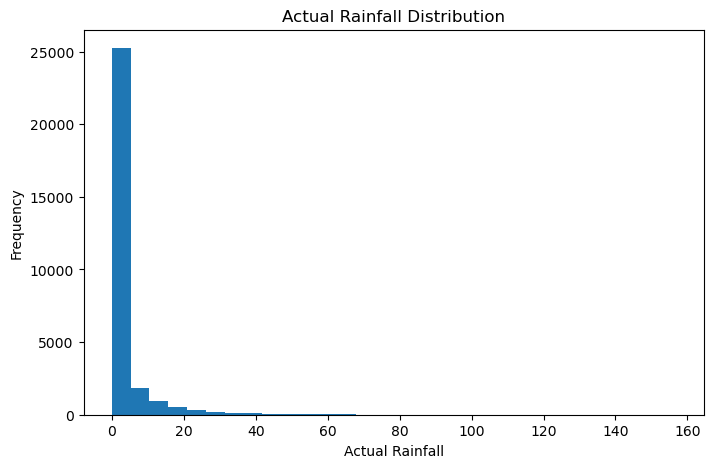

In [33]:
plt.figure(figsize=(8,5))

plt.hist(rainfall["actual"].dropna(), bins=30)

plt.title("Actual Rainfall Distribution")
plt.xlabel("Actual Rainfall")
plt.ylabel("Frequency")

plt.show()

In [34]:
## Normal Rainfall Distribution
rainfall["normal"].describe()

count    29583.000000
mean         2.592475
std          3.156027
min          0.000000
25%          0.200000
50%          0.800000
75%          4.700000
max         18.400000
Name: normal, dtype: float64

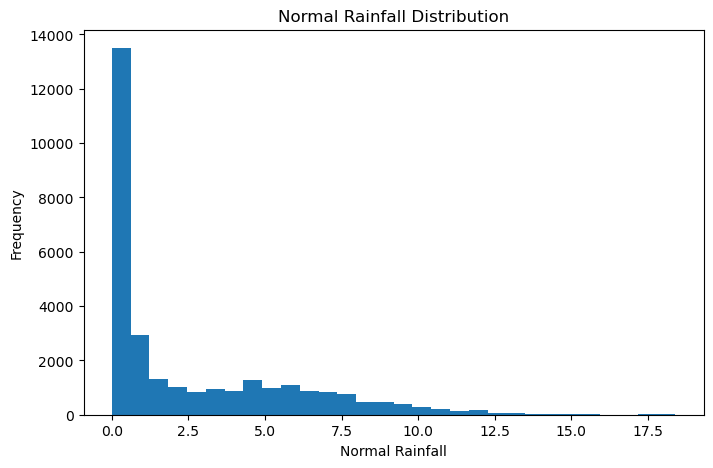

In [35]:
plt.figure(figsize=(8,5))

plt.hist(rainfall["normal"].dropna(), bins=30)

plt.title("Normal Rainfall Distribution")
plt.xlabel("Normal Rainfall")
plt.ylabel("Frequency")

plt.show()

In [36]:
## Rainfall Deviation Distribution
rainfall["deviation"].describe()

count    29583.000000
mean        43.426606
std        747.113575
min       -100.000000
25%       -100.000000
50%        -93.076923
75%          0.000000
max      37470.000000
Name: deviation, dtype: float64

In [38]:
## Total Actual Rainfall Trend by Agricultural Year
yearly_rainfall = (
    rainfall.groupby("agri_year")["actual"]
    .sum()
    .reset_index()
)

print(yearly_rainfall)

   agri_year    actual
0  2014-2015   6965.13
1  2015-2016   6998.69
2  2016-2017   9595.41
3  2017-2018   7988.12
4  2018-2019   8024.48
5  2019-2020  10299.45
6  2020-2021  11774.22
7  2021-2022  10769.78
8  2022-2023  12728.86


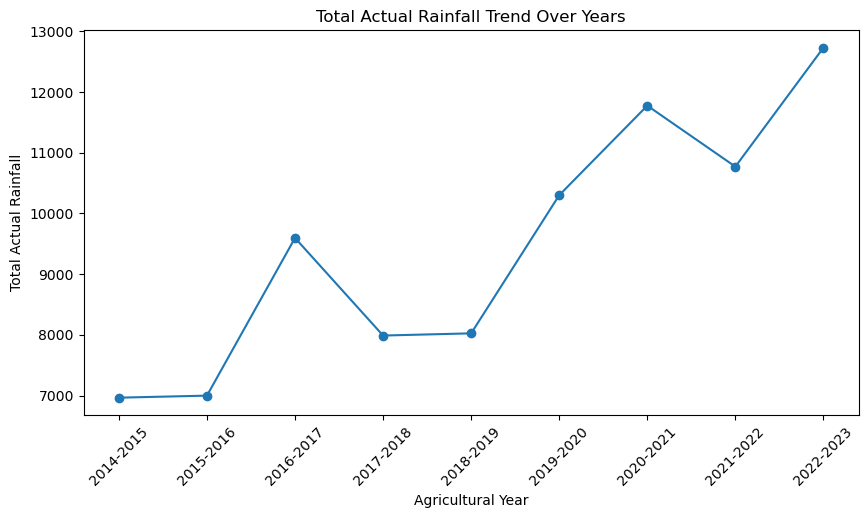

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_rainfall["agri_year"],
    yearly_rainfall["actual"],
    marker="o"
)

plt.title("Total Actual Rainfall Trend Over Years")
plt.xlabel("Agricultural Year")
plt.ylabel("Total Actual Rainfall")
plt.xticks(rotation=45)

plt.show()

## Bivariate Analysis 

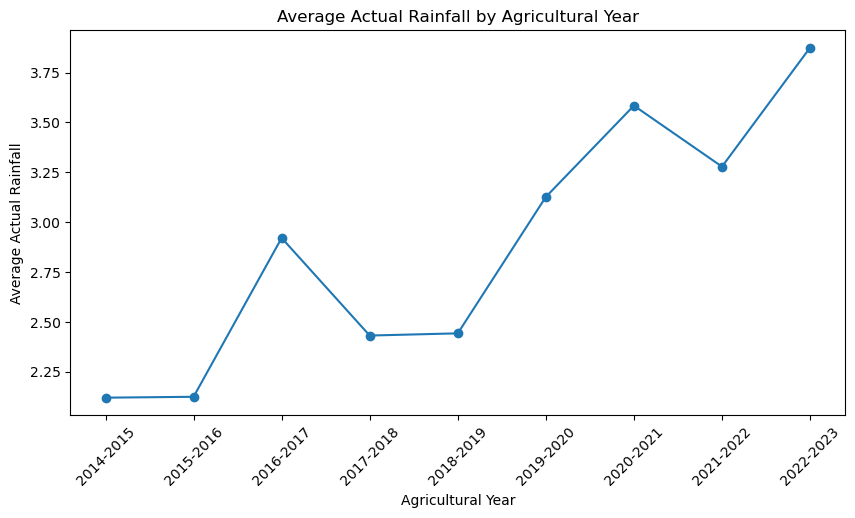

In [40]:
## Agricultural Year vs Actual Rainfall
yearly_rainfall = (
    rainfall.groupby("agri_year")["actual"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_rainfall["agri_year"],
    yearly_rainfall["actual"],
    marker="o"
)

plt.title("Average Actual Rainfall by Agricultural Year")
plt.xlabel("Agricultural Year")
plt.ylabel("Average Actual Rainfall")
plt.xticks(rotation=45)

plt.show()

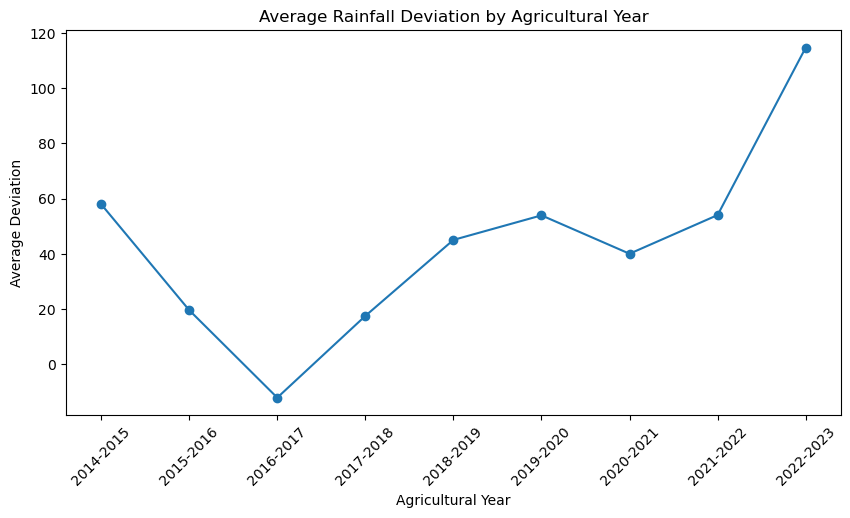

In [41]:
## Agricultural Year vs Rainfall Deviation
yearly_deviation = (
    rainfall.groupby("agri_year")["deviation"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deviation["agri_year"],
    yearly_deviation["deviation"],
    marker="o"
)

plt.title("Average Rainfall Deviation by Agricultural Year")
plt.xlabel("Agricultural Year")
plt.ylabel("Average Deviation")
plt.xticks(rotation=45)

plt.show()

In [42]:
## District vs Actual Rainfall
district_rainfall = (
    rainfall.groupby("district_name")["actual"]
    .mean()
    .sort_values(ascending=False)
)

print(district_rainfall)

district_name
Khammam         3.590138
Adilabad        3.422860
Warangal        3.309711
Karimnagar      3.180812
Nizamabad       3.035374
Medak           2.625462
Nalgonda        2.354988
Ranga Reddy     2.348179
Mahabubnagar    2.035773
Name: actual, dtype: float64


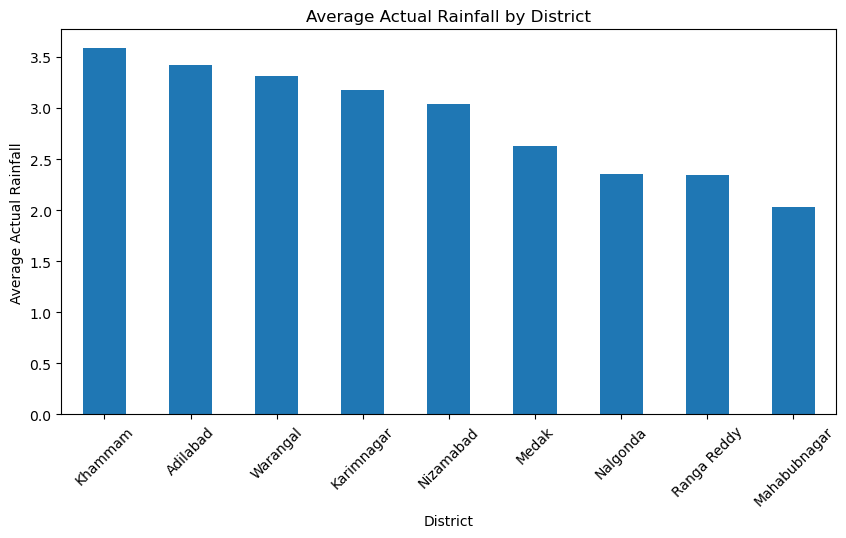

In [43]:
district_rainfall.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Actual Rainfall by District")
plt.xlabel("District")
plt.ylabel("Average Actual Rainfall")
plt.xticks(rotation=45)

plt.show()

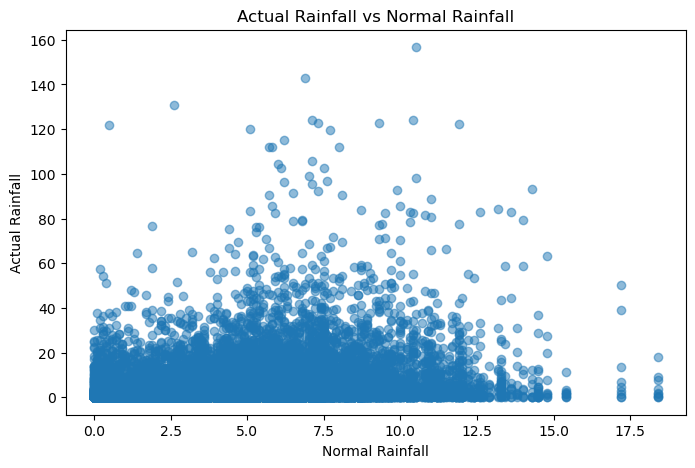

In [44]:
## Actual vs Normal Rainfall
plt.figure(figsize=(8,5))

plt.scatter(
    rainfall["normal"],
    rainfall["actual"],
    alpha=0.5
)

plt.title("Actual Rainfall vs Normal Rainfall")
plt.xlabel("Normal Rainfall")
plt.ylabel("Actual Rainfall")

plt.show()

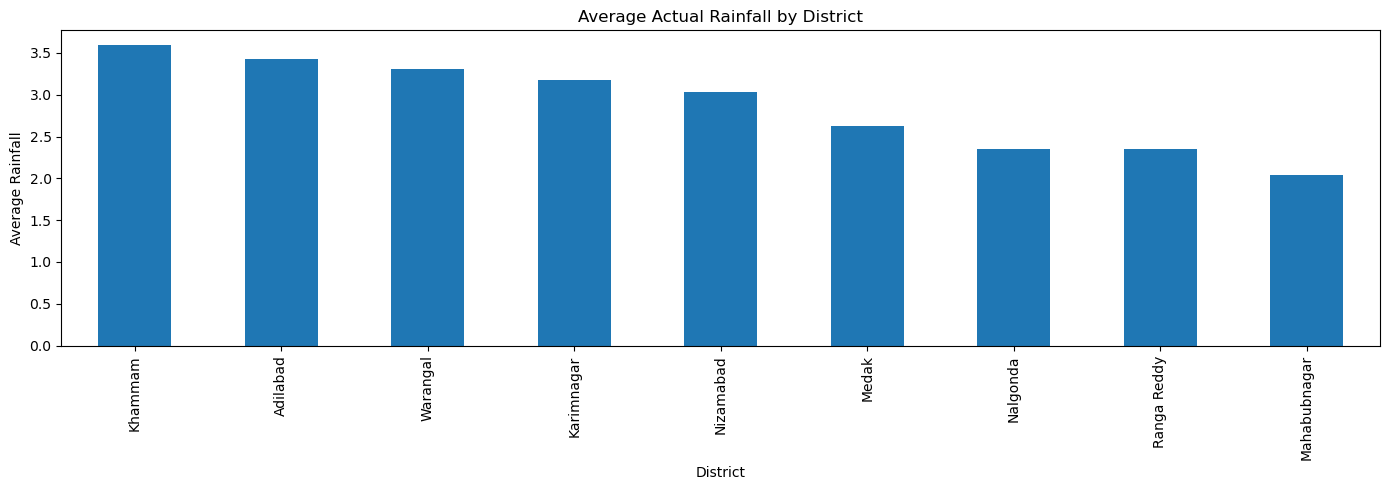

In [45]:
## Average Actual Rainfall by District
district_rainfall = (
    rainfall.groupby("district_name")["actual"]
    .mean()
    .sort_values(ascending=False)
)

district_rainfall.plot(
    kind="bar",
    figsize=(14, 5)
)

plt.title("Average Actual Rainfall by District")
plt.xlabel("District")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [46]:
## Correlation
print(
    rainfall[["actual", "normal"]].corr()
)

          actual    normal
actual  1.000000  0.376165
normal  0.376165  1.000000


## Multivariate Analysis 

In [47]:
## Actual + Normal + Deviation
rainfall[
    ["actual", "normal", "deviation"]
].corr()

,actual,normal,deviation
actual,1.000000,0.376165,0.312077
normal,0.376165,1.000000,-0.036511
deviation,0.312077,-0.036511,1.000000


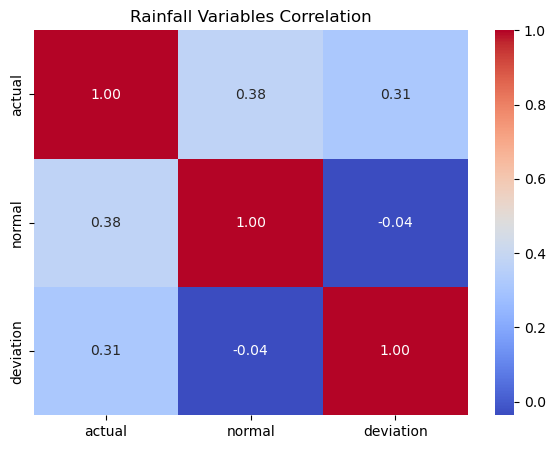

In [48]:

plt.figure(figsize=(7,5))

sns.heatmap(
    rainfall[
        ["actual", "normal", "deviation"]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Rainfall Variables Correlation")

plt.show()

In [49]:
## District + Agricultural Year + Actual Rainfall
district_year_rainfall = (
    rainfall.groupby(
        ["district_name", "agri_year"]
    )["actual"]
    .mean()
    .reset_index()
)

print(district_year_rainfall.head(20))

   district_name  agri_year    actual
0       Adilabad  2014-2015  2.639096
1       Adilabad  2015-2016  2.575792
2       Adilabad  2016-2017  3.474000
3       Adilabad  2017-2018  2.521534
4       Adilabad  2018-2019  3.567562
5       Adilabad  2019-2020  3.865246
6       Adilabad  2020-2021  3.054027
7       Adilabad  2021-2022  3.884110
8       Adilabad  2022-2023  5.225479
9     Karimnagar  2014-2015  2.329918
10    Karimnagar  2015-2016  2.445519
11    Karimnagar  2016-2017  3.149918
12    Karimnagar  2017-2018  2.443041
13    Karimnagar  2018-2019  2.993808
14    Karimnagar  2019-2020  3.702978
15    Karimnagar  2020-2021  3.778767
16    Karimnagar  2021-2022  3.460000
17    Karimnagar  2022-2023  4.323945
18       Khammam  2014-2015  2.563205
19       Khammam  2015-2016  3.056066


In [50]:
## District + Agricultural Year + Deviation
district_year_deviation = (
    rainfall.groupby(
        ["district_name", "agri_year"]
    )["deviation"]
    .mean()
    .reset_index()
)

print(district_year_deviation.head(20))

   district_name  agri_year   deviation
0       Adilabad  2014-2015   89.294537
1       Adilabad  2015-2016   14.616013
2       Adilabad  2016-2017  -22.997449
3       Adilabad  2017-2018   19.968105
4       Adilabad  2018-2019   75.474068
5       Adilabad  2019-2020   69.931180
6       Adilabad  2020-2021  -15.100530
7       Adilabad  2021-2022   47.542025
8       Adilabad  2022-2023   68.352253
9     Karimnagar  2014-2015  187.448433
10    Karimnagar  2015-2016   24.283041
11    Karimnagar  2016-2017  -28.312482
12    Karimnagar  2017-2018   21.813061
13    Karimnagar  2018-2019   84.148048
14    Karimnagar  2019-2020   90.277711
15    Karimnagar  2020-2021   32.958364
16    Karimnagar  2021-2022   31.093714
17    Karimnagar  2022-2023   67.992573
18       Khammam  2014-2015    6.442842
19       Khammam  2015-2016   31.845409


In [51]:
ml_path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"

rainfall.to_csv(
    ml_path + r"\Rainfall_Clean.csv",
    index=False
)

print("Rainfall_Clean.csv saved successfully.")

Rainfall_Clean.csv saved successfully.


## Insights 
- Actual Rainfall Distribution
  Actual rainfall has a mean of 2.89, a median of 0, and a maximum value of 156.68.
This shows that most daily observations have zero or low rainfall, while only a small number of observations have very high rainfall.
- Rainfall Across Agricultural Years
Total actual rainfall increased from approximately 6,965.13 in 2014–15 to 12,728.86 in 2022–23.
This shows that rainfall conditions vary considerably across agricultural years and should not be treated as constant over time.
- Rainfall Deviation
  Rainfall deviation ranges from -100 to 37,470, with a median of approximately -99.04.
The extremely high maximum values occur when actual rainfall is compared against very small normal rainfall values, creating extreme percentage deviations.